# AlphaFold2 — Structure Prediction

Visualization notebook: training curves, SE(3) noising, structure prediction, pLDDT, distance matrices.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path(".").resolve()))

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
from model import (
    AlphaFold2,
    RigidTransform,
    SE3Diffusion,
    backbone_from_frames,
    compute_local_frame,
)
from train import parse_pdb

model = AlphaFold2(plddt_weight=0.0).to(device)

# Note: checkpoint was trained with an older architecture (Evoformer + Structure Module).
# Current model uses Pairformer + SE(3) Diffusion. Load if compatible, otherwise use untrained.
ckpt = torch.load("checkpoint.pt", map_location=device, weights_only=True)
try:
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"AlphaFold2 loaded from checkpoint: {model.count_parameters():,} parameters")
except RuntimeError as e:
    print(f"Checkpoint incompatible with current architecture (trained with older Evoformer model).")
    print(f"Using untrained model for demonstration: {model.count_parameters():,} parameters")
model.eval()

pdb = parse_pdb(Path("../data/pdb/1CRN.pdb"))
true_N = pdb["coords_N"]
true_CA = pdb["coords_CA"]
true_C = pdb["coords_C"]
seq = pdb["sequence"].to(device)
L = true_CA.shape[0]
print(f"1CRN: {L} residues")

Checkpoint incompatible with current architecture (trained with older Evoformer model).
Using untrained model for demonstration: 8,821,880 parameters
1CRN: 46 residues


## 1. Training Curves

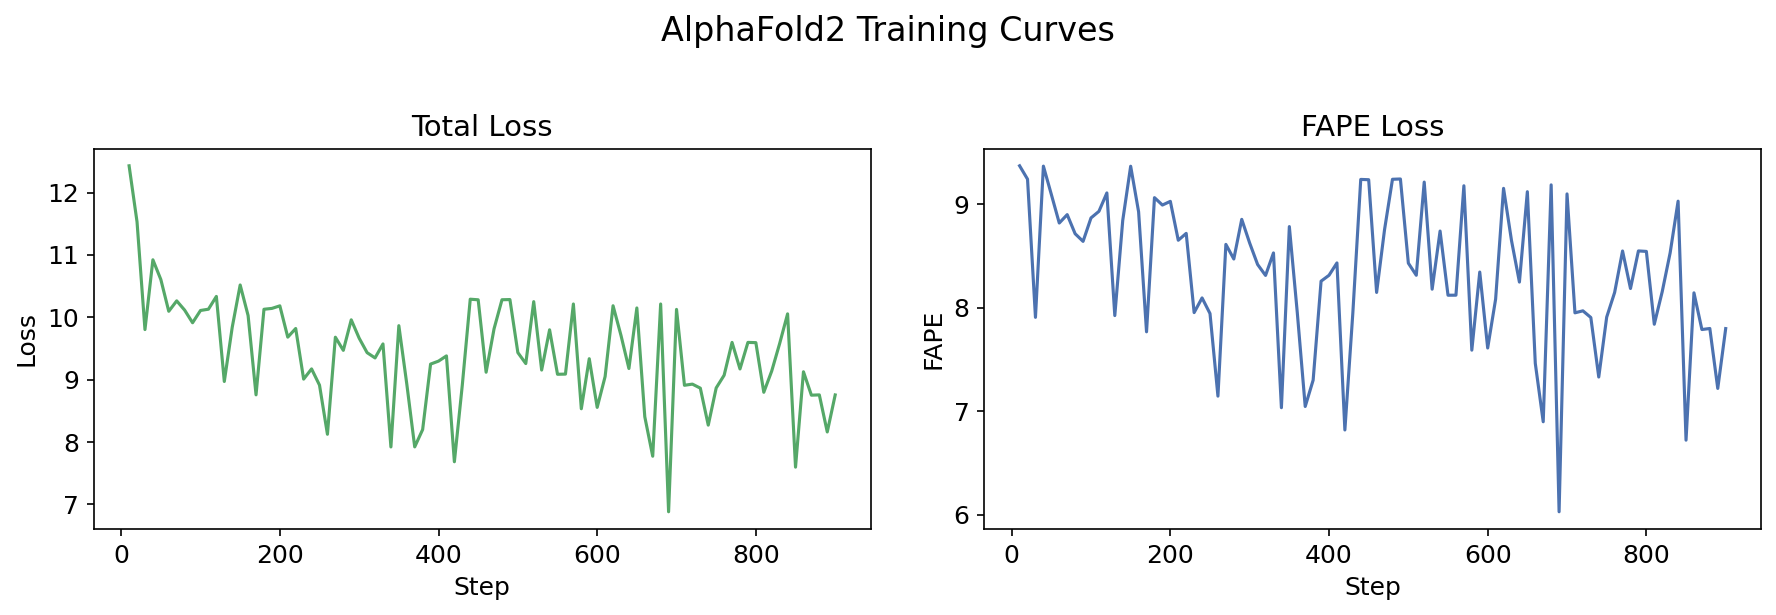

In [3]:
def parse_log(log_path, fields):
    """Parse training log. Returns dict of field_name -> list of floats."""
    data = {f: [] for f in fields}
    pattern = {f: re.compile(rf"{f}=([0-9eE.+-]+)") for f in fields}
    with open(log_path) as fh:
        for line in fh:
            if "step=" not in line:
                continue
            for f in fields:
                m = pattern[f].search(line)
                if m:
                    data[f].append(float(m.group(1)))
    return {f: np.array(v) for f, v in data.items()}


log = parse_log("../outputs/alphafold2/train.log", ["step", "loss", "fape"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log["step"], log["loss"], color="#55A868")
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Total Loss")

ax2.plot(log["step"], log["fape"], color="#4C72B0")
ax2.set_xlabel("Step")
ax2.set_ylabel("FAPE")
ax2.set_title("FAPE Loss")

fig.suptitle("AlphaFold2 Training Curves", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## 2. SE(3) Noising Process

Apply forward diffusion at increasing noise levels to visualize progressive corruption.

/tmp/ipykernel_2867144/2458030543.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


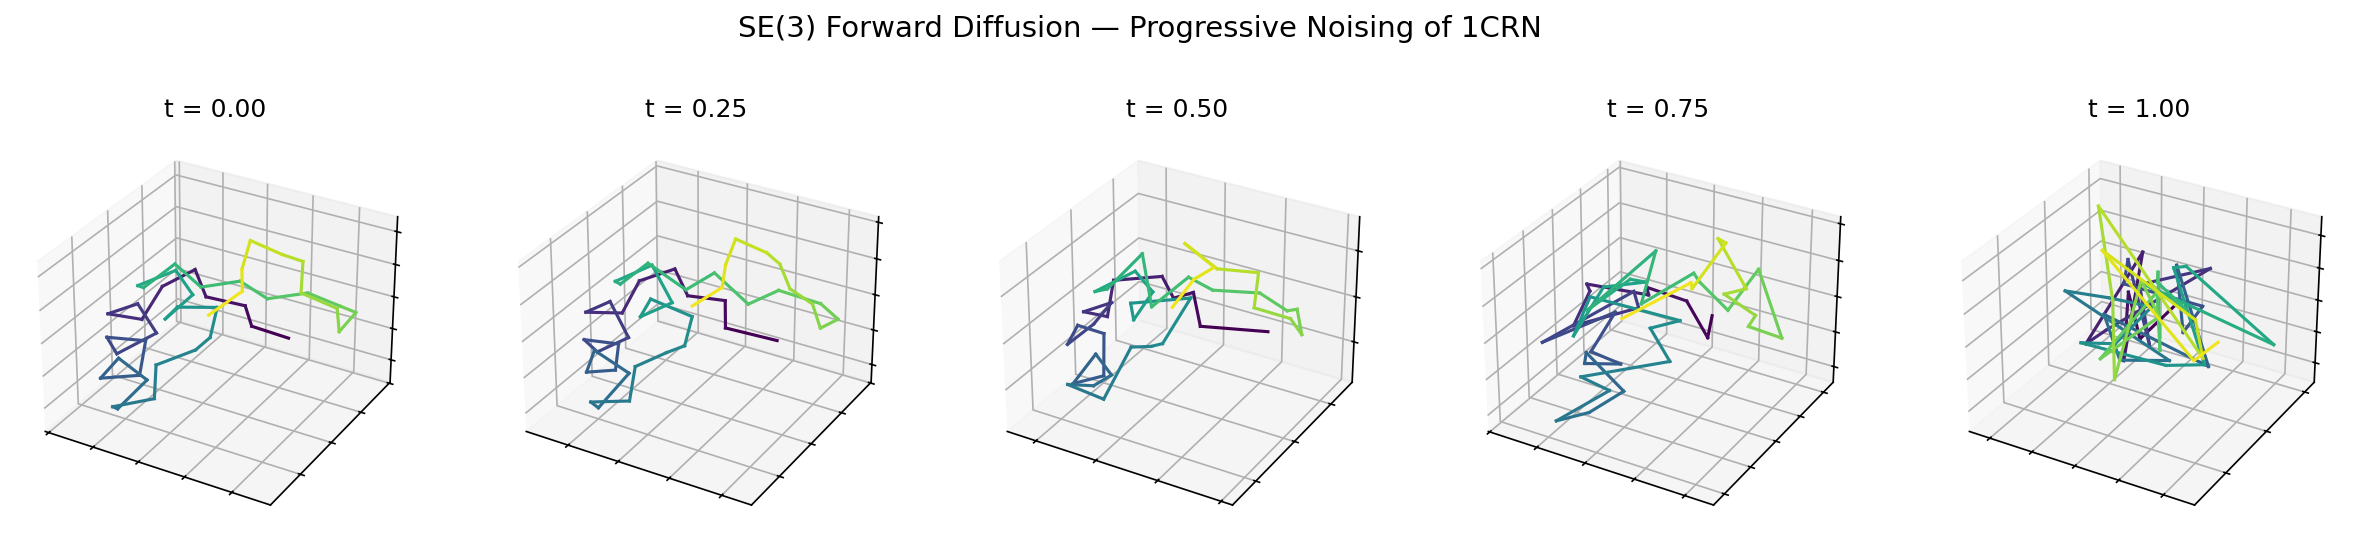

In [4]:
# Build frames from the real backbone
frames_0 = compute_local_frame(true_N, true_CA, true_C)  # [L]
diffusion = SE3Diffusion()

t_values = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={"projection": "3d"})

for ax, t in zip(axes, t_values):
    if t == 0.0:
        ca = true_CA.numpy()
    else:
        t_tensor = torch.full((L,), t)
        noisy_frames, _ = diffusion.forward_marginal(frames_0, t_tensor)
        _, noisy_ca, _ = backbone_from_frames(noisy_frames)
        ca = noisy_ca.detach().numpy()
    ca_c = ca - ca.mean(axis=0)
    colors = plt.cm.viridis(np.linspace(0, 1, L))
    for i in range(L - 1):
        ax.plot(ca_c[i:i+2, 0], ca_c[i:i+2, 1], ca_c[i:i+2, 2],
                color=colors[i], linewidth=1.5)
    ax.set_title(f"t = {t:.2f}", fontsize=12)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

fig.suptitle("SE(3) Forward Diffusion — Progressive Noising of 1CRN", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

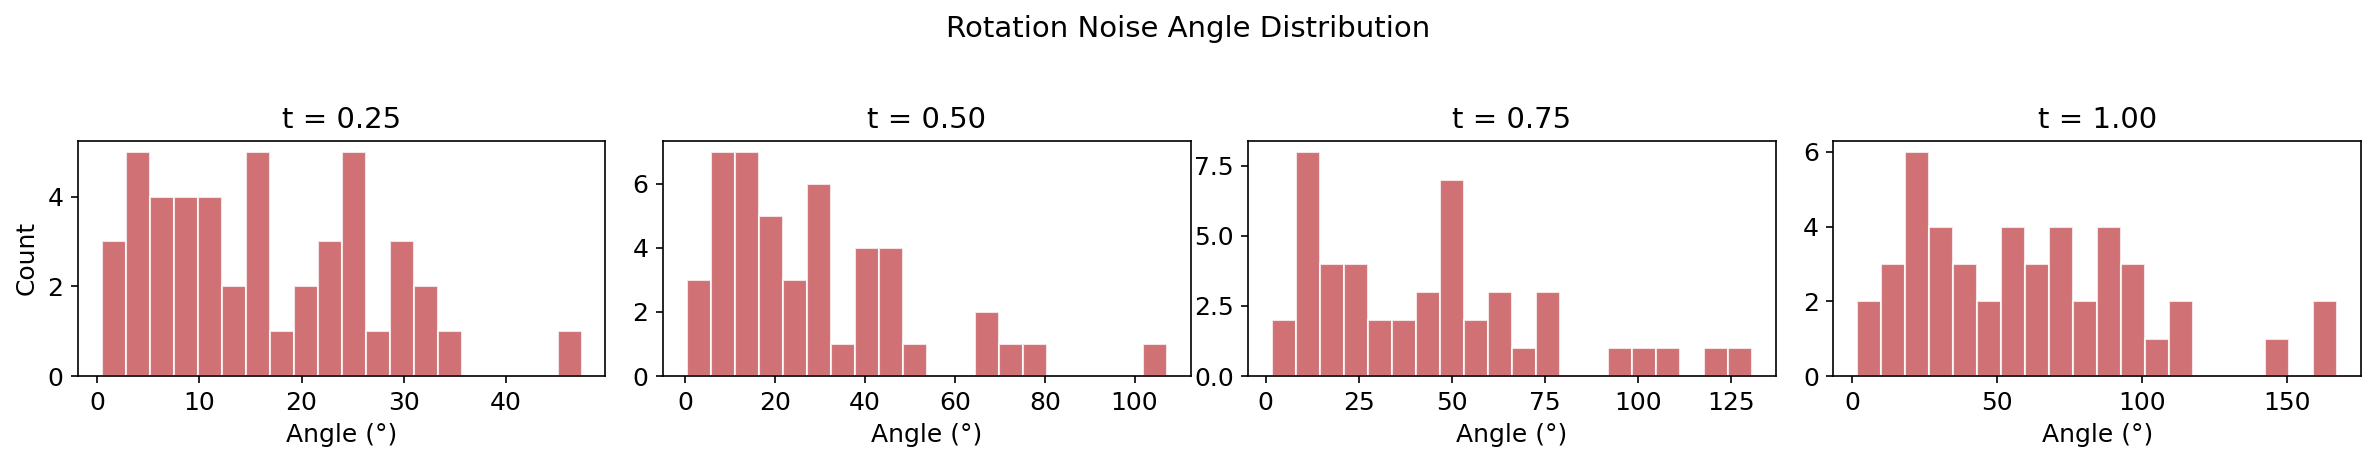

In [5]:
# Rotation angle distributions at each noise level
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, t in zip(axes, [0.25, 0.5, 0.75, 1.0]):
    t_tensor = torch.full((L,), t)
    noisy_frames, noise_dict = diffusion.forward_marginal(frames_0, t_tensor)
    # Compute rotation angles from noise rotations
    noise_rots = noise_dict["rot"]  # [L, 3, 3]
    trace = noise_rots[..., 0, 0] + noise_rots[..., 1, 1] + noise_rots[..., 2, 2]
    cos_angle = torch.clamp((trace - 1) / 2, -1, 1)
    angles = torch.acos(cos_angle).numpy() * 180 / np.pi  # degrees
    ax.hist(angles, bins=20, color="#C44E52", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Angle (\u00b0)")
    ax.set_title(f"t = {t:.2f}")
    if t == 0.25:
        ax.set_ylabel("Count")

fig.suptitle("Rotation Noise Angle Distribution", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 3. Structure Prediction

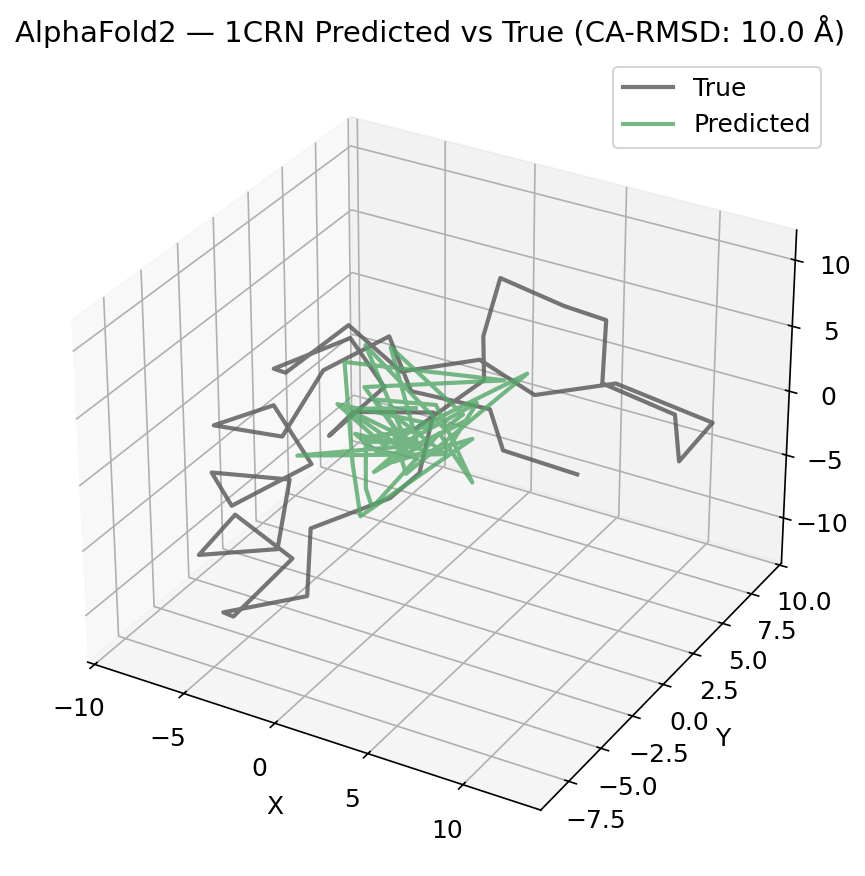

In [6]:
with torch.no_grad():
    pred = model.predict(seq)

pred_ca = pred["coords_CA"].cpu().numpy()  # [L, 3]
true_ca = true_CA.numpy()  # [L, 3]
plddt = pred["plddt"].cpu().numpy()  # [L]

# Center both
pred_centered = pred_ca - pred_ca.mean(axis=0)
true_centered = true_ca - true_ca.mean(axis=0)
rmsd = np.sqrt(((pred_centered - true_centered) ** 2).sum(axis=1).mean())

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(*true_centered.T, color="#555555", linewidth=2, label="True", alpha=0.8)
ax.plot(*pred_centered.T, color="#55A868", linewidth=2, label="Predicted", alpha=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"AlphaFold2 — 1CRN Predicted vs True (CA-RMSD: {rmsd:.1f} \u00c5)")
ax.legend()
fig.tight_layout()
plt.show()

## 4. pLDDT Confidence

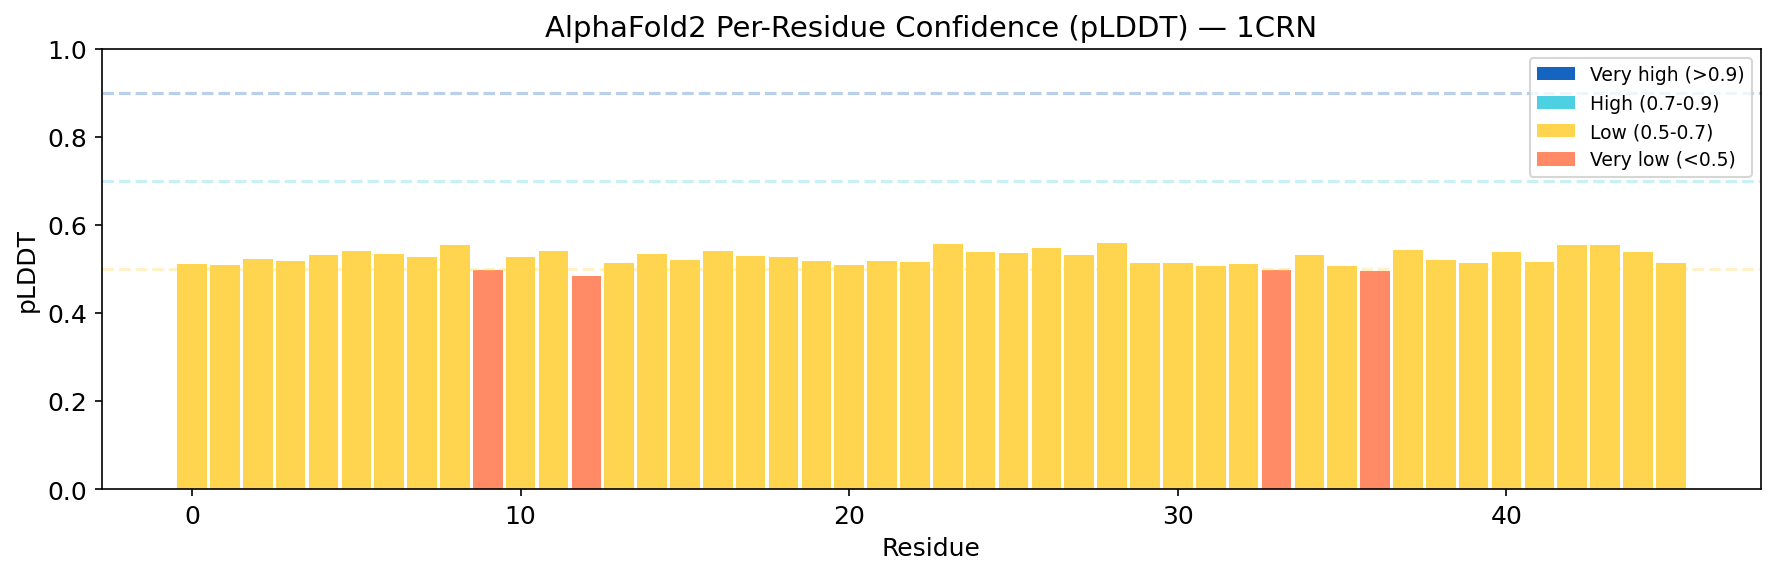

In [7]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 4))
colors_plddt = []
for v in plddt:
    if v > 0.9:
        colors_plddt.append("#1565C0")
    elif v > 0.7:
        colors_plddt.append("#4DD0E1")
    elif v > 0.5:
        colors_plddt.append("#FFD54F")
    else:
        colors_plddt.append("#FF8A65")

ax.bar(range(L), plddt, color=colors_plddt, width=0.9)
ax.axhline(y=0.9, color="#1565C0", linestyle="--", alpha=0.3)
ax.axhline(y=0.7, color="#4DD0E1", linestyle="--", alpha=0.3)
ax.axhline(y=0.5, color="#FFD54F", linestyle="--", alpha=0.3)
ax.set_xlabel("Residue")
ax.set_ylabel("pLDDT")
ax.set_ylim(0, 1)
ax.set_title("AlphaFold2 Per-Residue Confidence (pLDDT) — 1CRN")

legend_elements = [
    Patch(facecolor="#1565C0", label="Very high (>0.9)"),
    Patch(facecolor="#4DD0E1", label="High (0.7-0.9)"),
    Patch(facecolor="#FFD54F", label="Low (0.5-0.7)"),
    Patch(facecolor="#FF8A65", label="Very low (<0.5)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## 5. Distance Matrices

/tmp/ipykernel_2867144/839927600.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


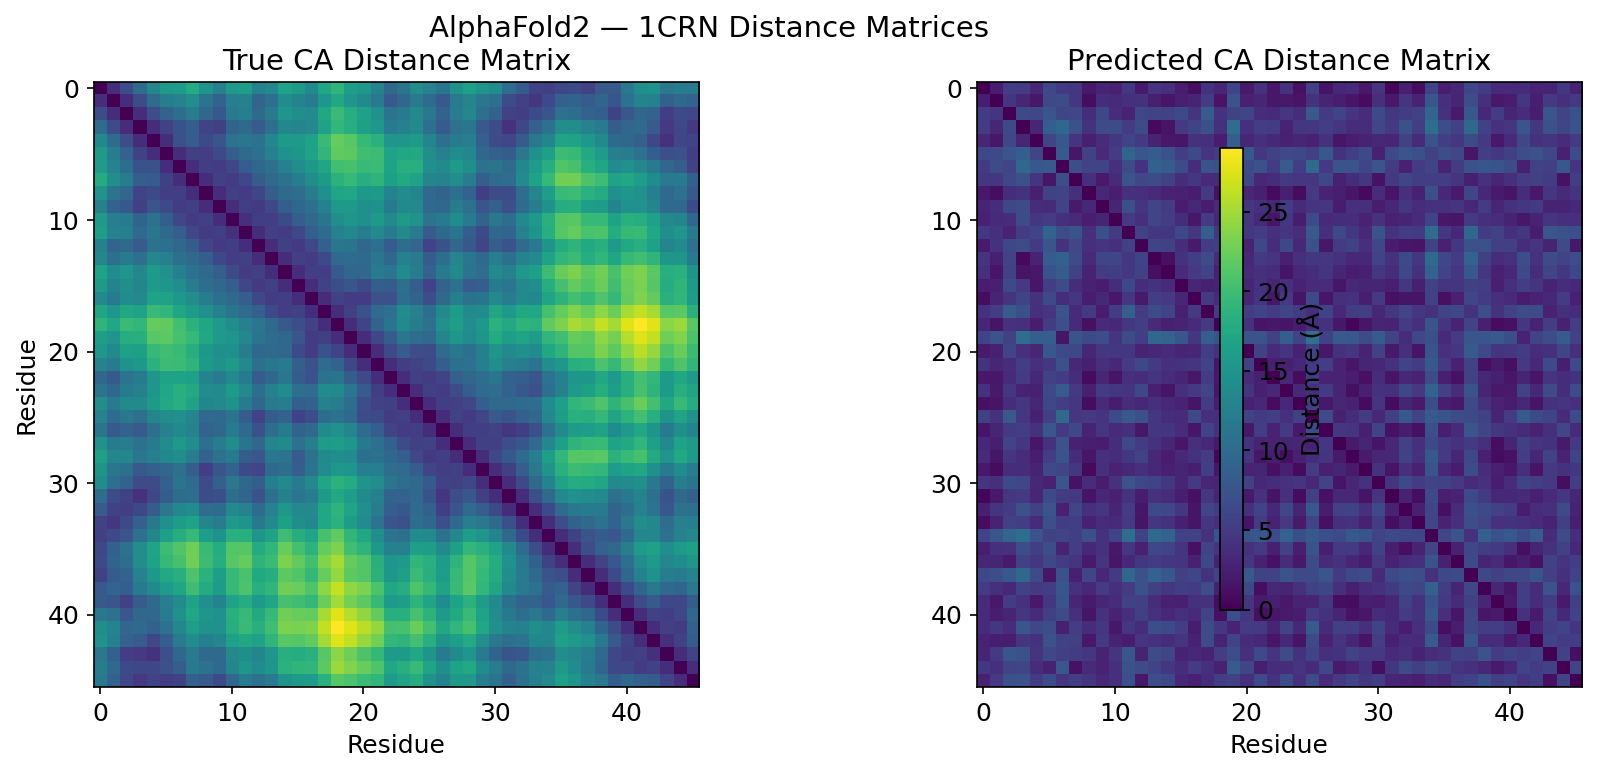

In [8]:
from scipy.spatial.distance import cdist

true_dist = cdist(true_centered, true_centered)
pred_dist = cdist(pred_centered, pred_centered)
vmin, vmax = 0, max(true_dist.max(), pred_dist.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(true_dist, cmap="viridis", vmin=vmin, vmax=vmax)
ax1.set_title("True CA Distance Matrix")
ax1.set_xlabel("Residue")
ax1.set_ylabel("Residue")

im2 = ax2.imshow(pred_dist, cmap="viridis", vmin=vmin, vmax=vmax)
ax2.set_title("Predicted CA Distance Matrix")
ax2.set_xlabel("Residue")

fig.colorbar(im2, ax=[ax1, ax2], shrink=0.8, label="Distance (\u00c5)")
fig.suptitle("AlphaFold2 — 1CRN Distance Matrices", fontsize=14)
fig.tight_layout()
plt.show()